In [1]:
# === TRANSFORMAÇÃO E ANÁLISE DO DATASET DDoS (versão Jupyter) ===

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [2]:
df_ddos = pd.read_csv("../datasets/DDoS.csv")

df_ddos.head()

,Highest Layer,Transport Layer,Source IP,Dest IP,Source Port,Dest Port,Packet Length,Packets/Time,target
0,ARP,UDP,1,192.168.1.1,0,0,60,92.8,1
1,ARP,UDP,0,192.168.1.10,0,0,42,92.9,0
2,ARP,UDP,1,192.168.1.1,0,0,60,362.8,1
3,ARP,UDP,0,192.168.1.12,0,0,42,362.8,0
4,ARP,UDP,1,192.168.1.1,0,0,60,364.3,1


In [3]:
df_ddos = df_ddos.drop(columns=["Source IP", "Dest IP"])

df_ddos = pd.get_dummies(df_ddos, columns=["Highest Layer", "Transport Layer"])

df_ddos.to_csv("../datasets/DDoS_transformado.csv", index=False, decimal=".", sep=";")
display(df_ddos.head())


,Source Port,Dest Port,Packet Length,Packets/Time,target,Highest Layer_ARP,Highest Layer_BOOTP,Highest Layer_BROWSER,Highest Layer_DATA,Highest Layer_DHCPV6,Highest Layer_LLMNR,Highest Layer_NBNS,Highest Layer_QUIC,Highest Layer_SSDP,Highest Layer_TCP,Transport Layer_TCP,Transport Layer_UDP
0,0,0,60,92.8,1,True,False,False,False,False,False,False,False,False,False,False,True
1,0,0,42,92.9,0,True,False,False,False,False,False,False,False,False,False,False,True
2,0,0,60,362.8,1,True,False,False,False,False,False,False,False,False,False,False,True
3,0,0,42,362.8,0,True,False,False,False,False,False,False,False,False,False,False,True
4,0,0,60,364.3,1,True,False,False,False,False,False,False,False,False,False,False,True


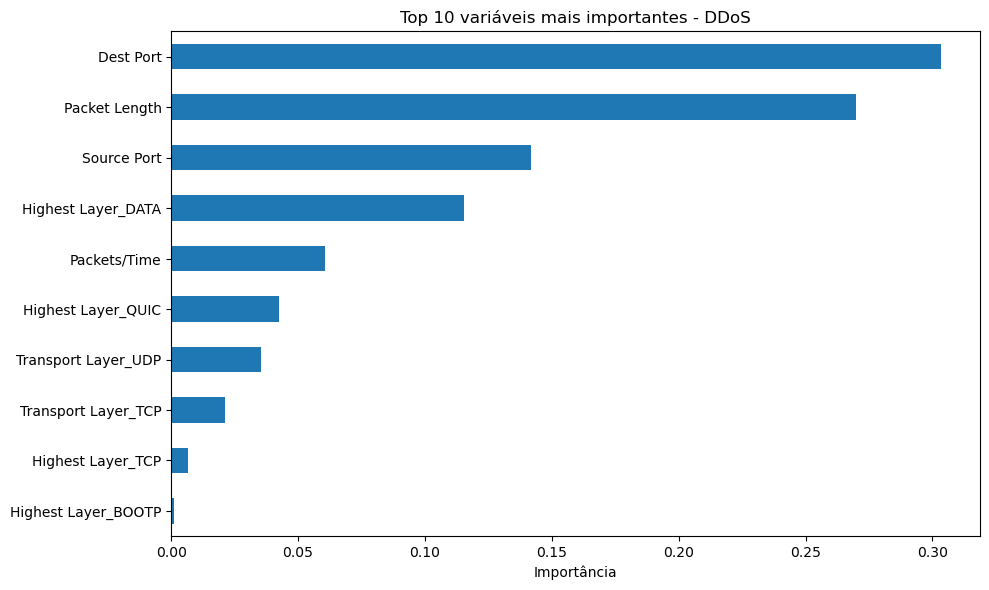

,importance
Dest Port,0.303589
Packet Length,0.269726
Source Port,0.141690
Highest Layer_DATA,0.115414
Packets/Time,0.060586
Highest Layer_QUIC,0.042638
Transport Layer_UDP,0.035373
Transport Layer_TCP,0.021019
Highest Layer_TCP,0.006612
Highest Layer_BOOTP,0.001158


In [4]:
Y = df_ddos["target"]
X = df_ddos.drop(columns="target")

modelo.fit(X, Y)

importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

top_n = 10
plt.figure(figsize=(10, 6))
importancias.head(top_n).plot(kind="barh")
plt.title(f"Top {top_n} variáveis mais importantes - DDoS")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(importancias.head(25).to_frame("importance"))
modelo = RandomForestClassifier(random_state=1000)
